## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Matthew Calvario

**Date:** 09/16/26

In [ ]:
# Your Phase 1 solution to the problem goes here.


1. What is the difference between regression and classification?

*Whereas Regression predicts continuous/numerical values, classification predicts discrete, categorical values. For example, a regression-based machine learning model may attempt predict the temperature in degrees given a few features in the dataset; by contrast, a classifier would utilize the different features to determine if the temperature outside is **warm** or **cold**.*

2. What is a confusion table? What does it help us understand about a model's performance?

*A confusion table is a matrix-style tool that is used to measure how well a classification model is performing. Specifically, it compares the true values on the vertical axis and the predicted values on the horizontal axis by categorizing them into four distinct groups:*
- True Positive (TP): Model correctly predicts a positive/"Yes" response
- True Negative (TN): Model correctly predicts a negative/"No" response
- False Positive  (FP): Model incorrectly predicts a positive/"Yes" response when the true response is negative
- False Negative (FN): Model incorrectly predicts a negative/"No" response when the true response is positive.

*In the case of multiclass classification (more than two labels), the diagonal represents correct classifications, while off-diagonal cells show which classes are being confused with one another.*

*Thus, rather than simply measuring accuracy over the total predictions, the confusion table provides a more comprehensive view of the model's performance by revealing the specific types of errors it made.*


3. What does the SSE quantify about a particular model?

*The Sum of Squared Errors quantifies the total prediction error of a given model by summing the squared differences between the predicted values and the actual values across all observation.*


4. What are overfitting and underfitting?

*Overfitting is when a given model overlearns a dataset, matching not just the shape of the sample but the noise and minor fluctuations as well (for k-NN, the k-value is very small). Conversely, underfitting occurs when the model is too simple to capture the underlying pattern of the training data (for k-NN, this means the k-value is very large).*

5. Why does splitting the data into training and testing sets, and choosing  𝑘  by evaluating accuracy or SSE on the test set, improve model performance?

*The benefits of splitting data into training and testing sets is to ensure that the final classifier is not just memorizing the pattern of the data but actually provides insights that are replicable across the dataset. This is because you can fit the data using the training set and then evaluate a candidate k's on the held-out test/validation set; thus, you can better discriminate what values of k are generalizing well vs. overfitting/underfitting the pattern.*

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

*The biggest strength of using class labels is providing a simple evaluation framework (think the confusion table) alongside direct action; there is no additional/amgbigious interpretation of the final output other than "Yes or No." However, one loses some nuance when using these forms of hard predictions. For example, a prediction that says "Yes" after a 51% majority ruling is treated the same as a "Yes" with a 99% majority.

*On the other hand, probability distributions in classification are very useful by quantifying this uncertainty, showing confidence levels to flag risky or ambiguous predictions. Furthermore, distributions allow one to adjust classification thresholds post-training more flexibly; That is, if one needed to add more weight towards false negatives than positives (due to their inherent cost in the context of its prediction), you are able to adjust precisely. That being said, using probability distributions can carry higher computing costs since its form of evaluation is more complex, requiring specific probabilistic metrics such as log loss or Brier scores. Additionally, classifying labels with this method requires additional calibration; in other words, the confidence score of the model does not always match its prediction of real-world values and often necessitates additional scrutiny and time for tuning.*

Question 2.

1. Load the data. Perform some EDA, summarizing the target label and the features.

2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)

3. Build a  𝑘 -NN classifier. Explain how you select  𝑘.

4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?

5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [1]:
!git clone https://github.com/Matthew-Calvario/A03-knn.git



Cloning into 'A03-knn'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 15 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 53.91 KiB | 1.42 MiB/s, done.
Resolving deltas: 100% (4/4), done.


,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


(338, 4)

array([1, 2, 3, 4, 5])

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


,voltage,height,soil,mine_type
333,0.323262,0.909091,0.4,5
334,0.444108,0.181818,1.0,5
335,0.353474,0.454545,1.0,5
336,0.362537,0.727273,1.0,5
337,0.314199,1.000000,1.0,5


,0
voltage,0
height,0
soil,0
mine_type,0


np.int64(0)

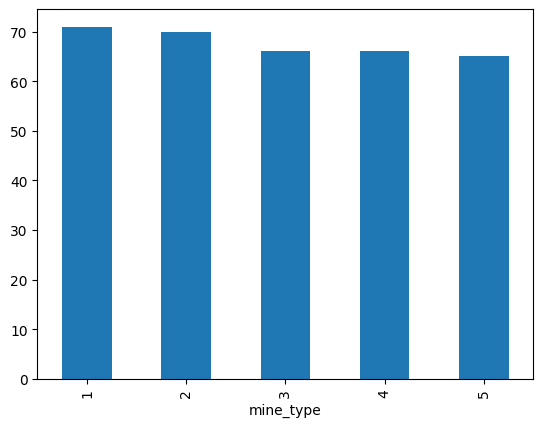

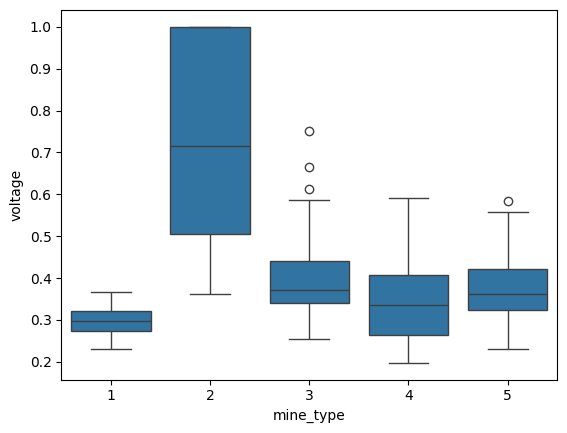

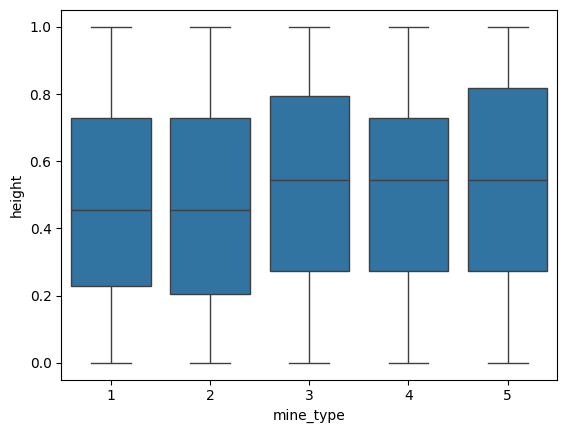

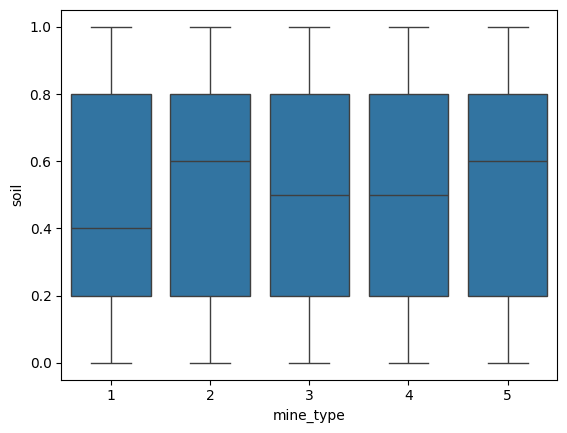


SUMMARY

338 observations, Target = mine_type, Predictors/features = voltage, height,
and soil; no missing values.

The distribution for mine_type is relatively even across all 5 types and
338 samples. Thus, it will be easier to mitigate the potential for the model
to have bias toward a particular class of mine.

All of the features have similar scales, with ranges from 0 to 1, with the
exception of voltage, which has a minimum value of 0.197. This suggests that
the data has already been normalized, so there is less risk of one of the
features disproportionately impacting kNN distance calculations.

The boxplots show that voltage may have the strongest apparent relationship
with mine type. Whereas height and soil have minimal variation across the
mine types, voltage level has a distinct spike at Mine Type 2. While the other
mine types have similar distributions and levels of voltage, this feature
appears to have the most promise for providing discriminatory information
regarding mine 

,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5
Actual 1,22,0,3,3,8
Actual 2,0,32,0,3,0
Actual 3,7,0,10,9,7
Actual 4,6,5,4,13,5
Actual 5,6,0,10,7,9



Based on the confusion table:

Overall Model Accuracy:
    (22 + 32 + 10 + 13 + 9) / 169
    = 0.5089
    = 50.89%

Most Accurate Class:
    Mine Type 2
    32 / 35 correct
    = 91.43%

Least Accurate Class:
    Mine Type 5
    9 / 32 correct
    = 28.13%


If I were to provide someone this model, I would tell them to be highly cautious
of predictions for Mine Types 3, 4, and 5, if not completely discourage them
from using those predictions because of 1) their sub-50% accuracy rates and
2) the large likelihood that they mistake their labels for one another.

Even for Mine Type 1, I would warn them to be judicious about making a decision
since its probability of correctness is barely above the chances of a coin toss.

The only label prediction that I would trust for the person to consider with
confidence is the Type 2 Mine prediction, which correctly identifies about
91% of actual Type 2 mines for this particular dataset and split. All things considered,
I would advise the user to uti

In [4]:
# Question 2.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Q2.1 - EDA/Summary of Data

df = pd.read_csv("A03-knn/data/land_mines.csv")

display(df.describe())
display(df.shape)
display(df['mine_type'].unique())
display(df.head())
display(df.tail())

# Check for na/NULL values
display(df.isna().sum())

# Check for duplicated values
display(df.duplicated().sum())

# Look at distribution of mine_type; appears to be relatively even in distribution
df['mine_type'].value_counts().plot(kind='bar')
plt.show()

# Look at distribution of mine_type across variables
sns.boxplot(data=df, x='mine_type', y='voltage')
plt.show()
sns.boxplot(data=df, x='mine_type', y='height')
plt.show()
sns.boxplot(data=df, x='mine_type', y='soil')
plt.show()

print("""
SUMMARY

338 observations, Target = mine_type, Predictors/features = voltage, height,
and soil; no missing values.

The distribution for mine_type is relatively even across all 5 types and
338 samples. Thus, it will be easier to mitigate the potential for the model
to have bias toward a particular class of mine.

All of the features have similar scales, with ranges from 0 to 1, with the
exception of voltage, which has a minimum value of 0.197. This suggests that
the data has already been normalized, so there is less risk of one of the
features disproportionately impacting kNN distance calculations.

The boxplots show that voltage may have the strongest apparent relationship
with mine type. Whereas height and soil have minimal variation across the
mine types, voltage level has a distinct spike at Mine Type 2. While the other
mine types have similar distributions and levels of voltage, this feature
appears to have the most promise for providing discriminatory information
regarding mine type prediction.
""")


# Q2.2 - Creating Testing and Training split

X = df.drop(columns ='mine_type')
y = df['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

# Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Q2.3 - Choosing k

# Find best value of k by looping through a range
k_values = np.arange(1,31)

# Store accuracies of different k-values
test_accuracies = []

for k in k_values:
  knn = KNeighborsClassifier(n_neighbors = k)
  knn.fit(X_train, y_train)

  y_pred = knn.predict(X_test)

  # Collect accuracy of the different k_values
  accuracy = accuracy_score(y_test, y_pred)
  test_accuracies.append((k, accuracy))

print(test_accuracies)
best_k, best_accuracy = max(test_accuracies, key=lambda x: x[1])

print("Best k:", best_k)
print(f"Best Accuracy: {best_accuracy:.2%}")

print("""
From the values 1-30 for k tested (for this split), k=1 yielded the highest
classification accuracy of the KNN models at 50.89%. Thus, for the final model,
I will use this value of k.

While very small values of k, like k=1, can be more sensitive to individual
observations, without a more robust validation approach (i.e. train-validate-test,
k-fold, etc.), k=1 is still the most appropriate choice because it produced the
highest accuracy on the provided validation set.
""")

# Final Model

knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train, y_train)

# Q2.4 - Confusion Table
y_pred = knn.predict(X_test)

c_table = confusion_matrix(y_test, y_pred)
print(c_table)

# Make table into dataframe for legibility

c_table_df = pd.DataFrame(
    c_table,
    index=["Actual 1", "Actual 2", "Actual 3", "Actual 4", "Actual 5"],
    columns=["Pred 1", "Pred 2", "Pred 3", "Pred 4", "Pred 5"]
)

display(c_table_df)

print("""
Based on the confusion table:

Overall Model Accuracy:
    (22 + 32 + 10 + 13 + 9) / 169
    = 0.5089
    = 50.89%

Most Accurate Class:
    Mine Type 2
    32 / 35 correct
    = 91.43%

Least Accurate Class:
    Mine Type 5
    9 / 32 correct
    = 28.13%
""")

# Q2.5 - Advising future model user

print("""
If I were to provide someone this model, I would tell them to be highly cautious
of predictions for Mine Types 3, 4, and 5, if not completely discourage them
from using those predictions because of 1) their sub-50% accuracy rates and
2) the large likelihood that they mistake their labels for one another.

Even for Mine Type 1, I would warn them to be judicious about making a decision
since its probability of correctness is barely above the chances of a coin toss.

The only label prediction that I would trust for the person to consider with
confidence is the Type 2 Mine prediction, which correctly identifies about
91% of actual Type 2 mines for this particular dataset and split. All things considered,
I would advise the user to utilize the tool as a support/screening tool rather than the sole
basis for safety-critical land-mine decision making because of how variable the
predictive accuracy can be.
""")



## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 4c275c0dcd10dc9b85f4bbd9628a8377f6265054
- **AI tool and model used:** GPT Sol 5.6 (high)

### *Prompts used

1. Review my complete Phase 1 notebook solution for correctness, clarity, efficiency, and adherence to the assignment requirements. First, identify any errors or questionable reasoning in my code, calculations, interpretations, visualizations, and written responses, and explain how they should be corrected. Then suggest thoughtful improvements that go beyond basic error-checking, such as cleaner or more efficient code, stronger visualizations, clearer output formatting, or more precise and insightful written explanations, while keeping the solution appropriate for the concepts covered. Provide a concise numbered list of your proposed changes so I can evaluate each suggestion individually (this formatting can be seen in the file)

2. Could you elaborate (referring to Improvement #3)

- Main subject of response: "The subtle issue is that once you use the held-out data to choose \(k\), that data is no longer functioning as a completely untouched "test" set. It is really acting as a validation set."

3. Please incorporate the suggestions but with minimal changes to my existing code; only water down the impact of high computing costs for probability distribution classifiers rather than completely take it out.

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Clarify the SSE explanation by giving the formula \(\sum (y_i-\hat y_i)^2\), noting that smaller SSE indicates predictions closer to the observed values and that squaring gives larger errors more influence. Also correct “across all observation” to “across all observations.”

2. Refine the overfitting/underfitting explanation so that small \(k\) and large \(k\) are described as tendencies rather than absolute rules. Overfitting should be connected to fitting training noise and poor generalization, while underfitting should be described as a model too simple to capture the underlying structure.

3. Distinguish validation data from true test data when selecting \(k\). Because the held-out set is used repeatedly to choose the best \(k\), it functions as a validation set rather than an untouched final test set. The assignment explicitly permits a “test/validation” set, so the current procedure is appropriate for the assignment, but the 50.89% accuracy should not be described as an independent final-test estimate.
4. Revise the class-label versus probability-distribution discussion. Remove the claim that probability predictions necessarily have meaningfully higher computational cost; instead emphasize that probabilities preserve uncertainty but may be poorly calibrated or sensitive to the model. Also generalize the discussion beyond “Yes/No,” since classification can have multiple classes, as in the five-class land-mine problem.

5. Make the EDA conclusions more precise. Report the class counts or proportions directly rather than only saying they are “relatively even,” and state that balanced classes reduce concerns about class imbalance rather than eliminating potential model bias. Also change “the data has already been normalized” to the more cautious observation that the predictors have already been rescaled to similar bounded ranges; this does not make additional standardization unnecessary for a distance-based method such as KNN.

6. Improve the EDA visualizations and interpretation. Add titles and axis labels to the class-frequency plot and boxplots, and replace wording such as a “distinct spike” in the Type 2 boxplot with more statistically appropriate language about its higher voltage distribution. Avoid claiming that a feature is strongly discriminatory unless the visualization clearly shows separation rather than simply a difference in distributions.

7. Improve the presentation of the \(k\)-selection process by plotting validation accuracy versus \(k\) instead of printing the entire list of 30 (k, accuracy) pairs. Keep the conclusion that \(k=1\) produced the highest observed accuracy, but emphasize that \(k=1\) is highly local and that its selection may be sensitive to this particular 50/50 split. Your scaling procedure itself is correct because the scaler is fit on the training data and only applied to the held-out data.

8. Calculate accuracy and class-level performance programmatically instead of hard-coding the confusion-table arithmetic. For example, calculate overall accuracy with accuracy_score() and derive row percentages from the confusion matrix so the written results automatically remain correct if the split or model changes. Also expand the Q2.4 interpretation beyond only the best and worst classes by mentioning important confusions, particularly the confusion among Types 3, 4, and 5.

9. Correct the Q2.5 interpretation by distinguishing recall from precision. The stated 91.43% for Type 2 means that 32 of 35 actual Type 2 mines were identified correctly (recall); it does not mean that 91.43% of predictions labeled Type 2 are correct. From the confusion table, Type 2 precision is \(32/37=86.49\%\), while Type 1 has 61.11% recall but only 53.66% precision. Remove the “coin toss” comparison because these class-specific rates are not directly comparable to a 50/50 coin flip. Types 3–5 perform poorly under both measures, strengthening the recommendation for caution.

10. Strengthen the practical-use recommendation while making it less absolute. Retain the good conclusion that this model should only be a screening/support tool in a safety-critical setting, but say that predictions—especially Types 3–5—should require independent confirmation rather than saying particular predictions should be completely disregarded. Explicitly note that these conclusions apply to this dataset and split and would need validation on additional data before deployment.

11. Clean up minor code and notebook presentation issues. Either use the currently imported classification_report to summarize per-class precision and recall or remove the unused import, replace redundant/raw output with labeled summaries, and keep the confusion table itself because the assignment specifically requests it. A normalized confusion-matrix heatmap could be added as a supplemental visualization without replacing the required raw table.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | **Accept** / modify / reject | A good improvement to enhance the precision of my original response alongside a typo fix. The formula is a good proof/visual, and the added note about smaller SSE being better is important to understand. |
| 2 | **Accept** / modify / reject | In this case, I think the small wording change that help with avoiding potentially absolute claims is imperative for scientific defintions and conclusions. |
| 3 | **Accept** / modify / reject | This was a mistake on my part by classifying the final result as a true test outcome; my version of testing does indeed act as a validation set since the final set is the one used to select the value of k. While this works as a form of validation before using the k-value on a truly-independent final set, it should not be described as anything other than a functional validation set. |
| 4 | Accept / **modify** / reject | I don't believe my description of higher computing costs is necessarily invalid, but I am open to lessening its impact if it isn't has important to the overall performance as a weakness. Other than that, I agree on keeping the calibration observation, as well as the generalization beyond binary classification--it was my mistake for narrowing the scope of these descriptions since there are various instances of multiple-class classification with KNN. |
| 5 | **Accept** / modify / reject | Good suggestion; provides a little more precision to my descriptions and less overly-certain wording. |
| 6 | **Accept** / modify / reject | Excellent addition for visual clarity as well as precision with wording--it is definitely true that odd distributions alone are not necessarily indicative of feature strength in prediction. Implementation shows much cleaner boxplots w/ labeling as well as more neutral wording for Type 2 mines. |
| 7 | **Accept** / modify / reject | Immediate fix; for Phase 1, I kept the KNN values all laid out for simplicity, but the actual output was jarring. I also like the additional emphasis for k = 1 being the best value since it prioritizes the sensitivity of this result from the 50/50 split despite the correct procedure being done.|
| 8 | **Accept** / modify / reject | Good form of generalization to replace hardcoding; I also believe the additional intrepration regarding the accuracy results paints the full picture of how the model struggles rather than simply pointing out the weakest and strongest classes. |
| 9 | **Accept** / modify / reject | Good correction of my misinterpration; correctly distinguishes recall from precision makes the description statistically accurate and avoids misleading comparisons about how well the model identifies versus predicts each class. |
| 10 | **Accept** / modify / reject | Good adjustment by remaining cautious and realistic whilst acknowledging the model's observed lack of generalizability beyond the dataset's train-test split. |
| 11 | **Accept** / modify / reject | Good overall recommendation; churned out a much better depiction of the test_accuracies list via a validation-accuracy plot, a labeled summary that has good information on precision and recall, and a visually-captivating normalized confusion-matrix. All data computationally checks out. |



### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


1. What is the difference between regression and classification?

*Whereas regression predicts continuous/numerical values, classification predicts discrete, categorical values. For example, a regression-based machine learning model may attempt to predict the temperature in degrees given a few features in the dataset; by contrast, a classifier would utilize the different features to determine if the temperature outside is **warm** or **cold**.*

2. What is a confusion table? What does it help us understand about a model's performance?

*A confusion table is a matrix-style tool that is used to measure how well a classification model is performing. Specifically, it compares the true values on the vertical axis and the predicted values on the horizontal axis by categorizing them into four distinct groups:*

- True Positive (TP): Model correctly predicts a positive/"Yes" response
- True Negative (TN): Model correctly predicts a negative/"No" response
- False Positive (FP): Model incorrectly predicts a positive/"Yes" response when the true response is negative
- False Negative (FN): Model incorrectly predicts a negative/"No" response when the true response is positive.

*In the case of multiclass classification (more than two labels), the diagonal represents correct classifications, while off-diagonal cells show which classes are being confused with one another.*

*Thus, rather than simply measuring accuracy over the total predictions, the confusion table provides a more comprehensive view of the model's performance by revealing the specific types of errors it made.*


3. What does the SSE quantify about a particular model?

*The Sum of Squared Errors quantifies the total prediction error of a given model by summing the squared differences between the predicted values and the actual values across all observations:*

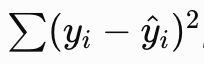

*where y_i is the actual value and ({y}_i)^ is the predicted value. A smaller SSE indicates that the model's predictions are generally closer to the observed values. Because the errors are squared, larger errors receive more weight in the total.*


4. What are overfitting and underfitting?

*Overfitting is when a given model overlearns a dataset, matching not just the underlying pattern of the sample but the noise and minor fluctuations as well. For k-NN, very small values of k tend to increase the risk of overfitting because predictions depend on only a small number of nearby observations. Conversely, underfitting occurs when the model is too simple to capture the underlying pattern of the training data. For k-NN, very large values of k tend to increase the risk of underfitting because the model averages over many observations and can smooth away meaningful local patterns.*


5. Why does splitting the data into training and testing sets, and choosing 𝑘 by evaluating accuracy or SSE on the test set, improve model performance?

*The benefit of splitting data into training and testing sets is to ensure that the final classifier is not just memorizing the pattern of the data but actually provides insights that are replicable across unseen observations. This is because you can fit the model using the training set and then evaluate candidate values of k on a held-out test/validation set; thus, you can better discriminate which values of k are generalizing well versus overfitting or underfitting the pattern.*

*More precisely, when the held-out set is repeatedly used to compare candidate values of k, it functions as a validation set because it is being used to make a modeling decision. A completely independent test set would ideally be evaluated only after the final value of k has been selected. However, for a smaller dataset and the 50/50 train-test/validation procedure specified in this assignment, the held-out set can reasonably serve this model-selection purpose.*


6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

*The biggest strength of using class labels is providing a simple evaluation framework (think the confusion table) alongside direct action; the final output directly assigns the observation to a particular class. However, one loses some nuance when using these forms of hard predictions. For example, a prediction made with only a slight preference for one class is treated the same as a prediction where one class is overwhelmingly favored.*

*On the other hand, probability distributions in classification are very useful for quantifying this uncertainty, showing how strongly the model favors each possible class and helping flag risky or ambiguous predictions. Furthermore, probability distributions allow decision rules or classification thresholds to be adjusted more flexibly when different types of mistakes have different costs. For example, if false negatives were more consequential than false positives, the decision threshold could potentially be adjusted accordingly.*

*That being said, probability-based predictions require additional interpretation and scrutiny. Most importantly, the probability or confidence reported by a model is not necessarily perfectly calibrated to real-world outcomes. A prediction assigned a probability of 90%, for example, does not automatically mean that comparable predictions will actually be correct 90% of the time. These estimates can also be sensitive to the model and its settings; in k-NN, for instance, estimated class probabilities depend on the composition of the nearest neighbors and the chosen value of k. Probability-based approaches can also carry somewhat greater computational and evaluation costs because probabilities must be generated and may require additional metrics, such as log loss or Brier scores, but this is generally a secondary concern compared with ensuring that the probabilities are well-calibrated and interpreted appropriately.*

,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


(338, 4)

array([1, 2, 3, 4, 5])

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


,voltage,height,soil,mine_type
333,0.323262,0.909091,0.4,5
334,0.444108,0.181818,1.0,5
335,0.353474,0.454545,1.0,5
336,0.362537,0.727273,1.0,5
337,0.314199,1.000000,1.0,5


,0
voltage,0
height,0
soil,0
mine_type,0


np.int64(0)

,count,proportion
mine_type,,
1,71,0.210059
2,70,0.207101
3,66,0.195266
4,66,0.195266
5,65,0.192308


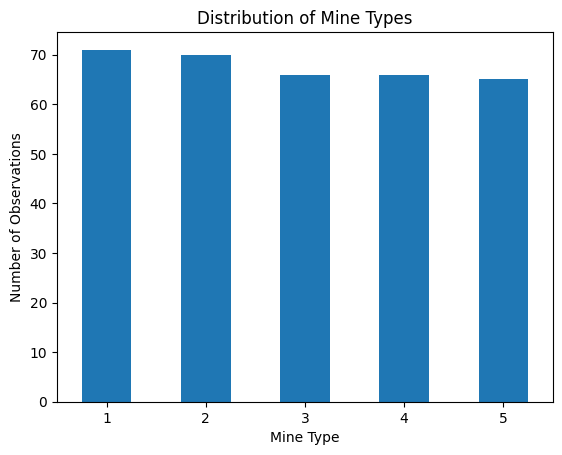

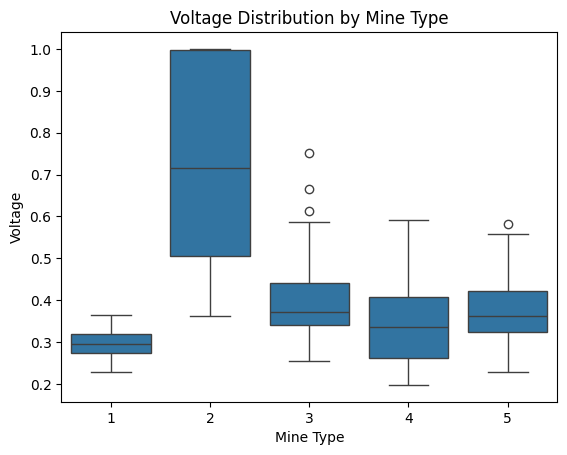

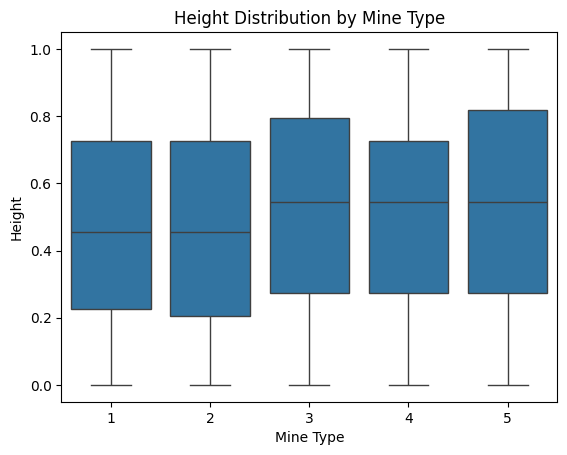

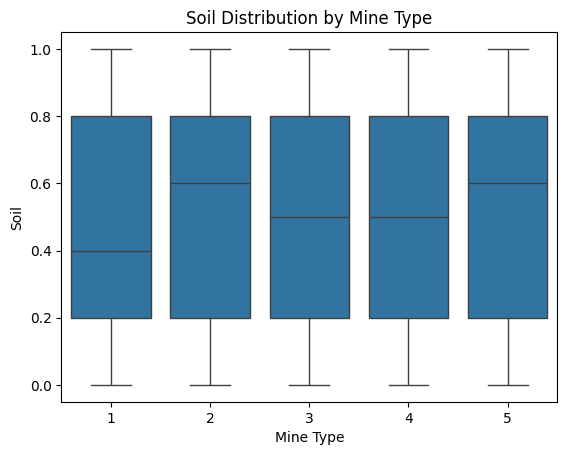


SUMMARY

338 observations, Target = mine_type, Predictors/features = voltage, height,
and soil; no missing values.

The distribution for mine_type is relatively even across all 5 types and
338 samples. Specifically, there are 71 Type 1, 70 Type 2, 66 Type 3,
66 Type 4, and 65 Type 5 observations. Thus, there is relatively little
class imbalance, which reduces concern that the model's overall performance
will be dominated by one much larger class. However, balanced class sizes
do not by themselves eliminate other potential sources of model bias or
differences in class-specific performance.

All of the features are already bounded on similar scales, with ranges from
0 to 1, with the exception of voltage, which has a minimum value of about
0.197. This suggests that the predictors have already been rescaled to
similar ranges. However, because k-NN directly relies on distances between
observations, I will still standardize the predictors using the training
data so differences in feature di

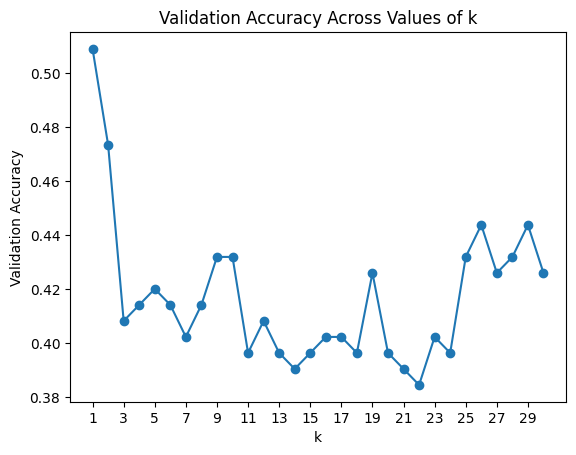

Best k: 1
Best Accuracy: 50.89%

From the values 1-30 for k tested (for this split), k=1 yielded the
highest classification accuracy of the KNN models at 50.89%.
Thus, for the final model, I will use this value of k.

While very small values of k, like k=1, can be more sensitive to individual
observations and therefore have a greater risk of overfitting, k=1 is the
best-performing value among the candidate values tested on this particular
held-out split.

Because this same held-out set was used to compare and select values of k,
it is functioning as a validation set rather than a completely independent
final test set. Therefore, the 50.89% should be interpreted as
validation performance for this particular split rather than as an unbiased
estimate of final test performance.

A more robust approach could use a separate train-validation-test split or
cross-validation to select k before evaluating the final model on untouched
test data. However, given the assignment's specified 50/50 trai

,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5
Actual 1,22,0,3,3,8
Actual 2,0,32,0,3,0
Actual 3,7,0,10,9,7
Actual 4,6,5,4,13,5
Actual 5,6,0,10,7,9


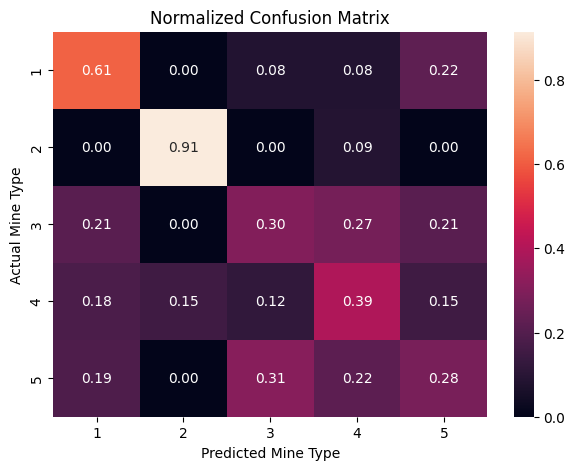

,Precision,Recall
Mine Type,,
1,0.537,0.611
2,0.865,0.914
3,0.370,0.303
4,0.371,0.394
5,0.310,0.281


,precision,recall,f1-score,support
1,0.537,0.611,0.571,36.000
2,0.865,0.914,0.889,35.000
3,0.370,0.303,0.333,33.000
4,0.371,0.394,0.382,33.000
5,0.310,0.281,0.295,32.000
accuracy,0.509,0.509,0.509,0.509
macro avg,0.491,0.501,0.494,169.000
weighted avg,0.497,0.509,0.501,169.000



Based on the confusion table:

Overall Model Accuracy:
    50.89%

Highest Recall:
    Mine Type 2
    91.43% of actual Type 2
    mines were correctly identified.

Lowest Recall:
    Mine Type 5
    28.12% of actual Type 5
    mines were correctly identified.

The diagonal of the confusion table represents correct predictions, while
the off-diagonal entries represent errors. The table shows particularly
strong performance for Mine Type 2, while Types 3, 4, and 5 have considerably
lower recall and are frequently confused with other classes.

The normalized confusion matrix makes these differences easier to compare
across classes because each row represents the proportion of observations
within an actual mine type rather than only the raw number of observations.


If I were to provide someone this model, I would tell them to be highly cautious
of predictions for Mine Types 3, 4, and 5 because both their precision and recall
are relatively low, and the confusion table shows that these c

In [3]:
# Question 2.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Q2.1 - EDA/Summary of Data

df = pd.read_csv("A03-knn/data/land_mines.csv")

display(df.describe())
display(df.shape)
display(df['mine_type'].unique())
display(df.head())
display(df.tail())

# Check for na/NULL values
display(df.isna().sum())

# Check for duplicated values
display(df.duplicated().sum())

# Look at counts and proportions of mine_type
class_summary = pd.DataFrame({
    'count': df['mine_type'].value_counts().sort_index(),
    'proportion': df['mine_type'].value_counts(normalize=True).sort_index()
})

display(class_summary)

# Look at distribution of mine_type; appears to be relatively even in distribution
df['mine_type'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Mine Types')
plt.xlabel('Mine Type')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.show()

# Look at distribution of mine_type across variables
sns.boxplot(data=df, x='mine_type', y='voltage')
plt.title('Voltage Distribution by Mine Type')
plt.xlabel('Mine Type')
plt.ylabel('Voltage')
plt.show()

sns.boxplot(data=df, x='mine_type', y='height')
plt.title('Height Distribution by Mine Type')
plt.xlabel('Mine Type')
plt.ylabel('Height')
plt.show()

sns.boxplot(data=df, x='mine_type', y='soil')
plt.title('Soil Distribution by Mine Type')
plt.xlabel('Mine Type')
plt.ylabel('Soil')
plt.show()

print("""
SUMMARY

338 observations, Target = mine_type, Predictors/features = voltage, height,
and soil; no missing values.

The distribution for mine_type is relatively even across all 5 types and
338 samples. Specifically, there are 71 Type 1, 70 Type 2, 66 Type 3,
66 Type 4, and 65 Type 5 observations. Thus, there is relatively little
class imbalance, which reduces concern that the model's overall performance
will be dominated by one much larger class. However, balanced class sizes
do not by themselves eliminate other potential sources of model bias or
differences in class-specific performance.

All of the features are already bounded on similar scales, with ranges from
0 to 1, with the exception of voltage, which has a minimum value of about
0.197. This suggests that the predictors have already been rescaled to
similar ranges. However, because k-NN directly relies on distances between
observations, I will still standardize the predictors using the training
data so differences in feature distributions do not disproportionately
influence the distance calculations.

The boxplots show that voltage may have the strongest apparent relationship
with mine type. Mine Type 2 has a noticeably higher voltage distribution
than many of the other classes, while the distributions of height and soil
show substantial overlap across mine types. Thus, voltage appears to provide
some useful discriminatory information, although the overlap between classes
suggests that no single feature perfectly separates the mine types.
""")

# Q2.2 - Creating Testing and Training split

X = df.drop(columns='mine_type')
y = df['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

# Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Q2.3 - Choosing k

# Find best value of k by looping through a range
k_values = np.arange(1,31)

# Store accuracies of different k-values
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    # Collect accuracy of the different k_values
    accuracy = accuracy_score(y_test, y_pred)
    test_accuracies.append((k, accuracy))

# Plot validation accuracy for each value of k
accuracy_values = [accuracy for k, accuracy in test_accuracies]

plt.plot(k_values, accuracy_values, marker='o')
plt.title('Validation Accuracy Across Values of k')
plt.xlabel('k')
plt.ylabel('Validation Accuracy')
plt.xticks(np.arange(1, 31, 2))
plt.show()

best_k, best_accuracy = max(test_accuracies, key=lambda x: x[1])

print("Best k:", best_k)
print(f"Best Accuracy: {best_accuracy:.2%}")

print(f"""
From the values 1-30 for k tested (for this split), k={best_k} yielded the
highest classification accuracy of the KNN models at {best_accuracy:.2%}.
Thus, for the final model, I will use this value of k.

While very small values of k, like k=1, can be more sensitive to individual
observations and therefore have a greater risk of overfitting, k=1 is the
best-performing value among the candidate values tested on this particular
held-out split.

Because this same held-out set was used to compare and select values of k,
it is functioning as a validation set rather than a completely independent
final test set. Therefore, the {best_accuracy:.2%} should be interpreted as
validation performance for this particular split rather than as an unbiased
estimate of final test performance.

A more robust approach could use a separate train-validation-test split or
cross-validation to select k before evaluating the final model on untouched
test data. However, given the assignment's specified 50/50 train and
test/validation procedure, k={best_k} is the most appropriate choice from
the values tested here.
""")

# Final Model

knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train, y_train)

# Q2.4 - Confusion Table

y_pred = knn.predict(X_test)

c_table = confusion_matrix(y_test, y_pred)

# Make table into dataframe for legibility

labels = np.sort(y.unique())

c_table_df = pd.DataFrame(
    c_table,
    index=[f"Actual {label}" for label in labels],
    columns=[f"Pred {label}" for label in labels]
)

display(c_table_df)

# Create a row-normalized version of the confusion table
# Each row shows how actual observations of a class were distributed
c_table_normalized = (
    c_table / c_table.sum(axis=1, keepdims=True)
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    c_table_normalized,
    annot=True,
    fmt='.2f',
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted Mine Type')
plt.ylabel('Actual Mine Type')
plt.show()

# Overall model accuracy
overall_accuracy = accuracy_score(y_test, y_pred)

# Calculate class-specific recall and precision directly from confusion table
class_recall = np.diag(c_table) / c_table.sum(axis=1)
class_precision = np.diag(c_table) / c_table.sum(axis=0)

class_performance = pd.DataFrame({
    'Mine Type': labels,
    'Precision': class_precision,
    'Recall': class_recall
}).set_index('Mine Type')

display(class_performance.round(3))

# Classification report for additional class-level performance information
report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
display(report_df.round(3))

# Identify highest and lowest class recall programmatically
best_recall_index = np.argmax(class_recall)
worst_recall_index = np.argmin(class_recall)

best_recall_class = labels[best_recall_index]
worst_recall_class = labels[worst_recall_index]

print(f"""
Based on the confusion table:

Overall Model Accuracy:
    {overall_accuracy:.2%}

Highest Recall:
    Mine Type {best_recall_class}
    {class_recall[best_recall_index]:.2%} of actual Type {best_recall_class}
    mines were correctly identified.

Lowest Recall:
    Mine Type {worst_recall_class}
    {class_recall[worst_recall_index]:.2%} of actual Type {worst_recall_class}
    mines were correctly identified.

The diagonal of the confusion table represents correct predictions, while
the off-diagonal entries represent errors. The table shows particularly
strong performance for Mine Type 2, while Types 3, 4, and 5 have considerably
lower recall and are frequently confused with other classes.

The normalized confusion matrix makes these differences easier to compare
across classes because each row represents the proportion of observations
within an actual mine type rather than only the raw number of observations.
""")

# Q2.5 - Advising future model user

type1_precision = class_performance.loc[1, 'Precision']
type1_recall = class_performance.loc[1, 'Recall']

type2_precision = class_performance.loc[2, 'Precision']
type2_recall = class_performance.loc[2, 'Recall']

print(f"""
If I were to provide someone this model, I would tell them to be highly cautious
of predictions for Mine Types 3, 4, and 5 because both their precision and recall
are relatively low, and the confusion table shows that these classes are
frequently mistaken for one another. Predictions in these categories should
therefore require independent confirmation rather than being treated as
sufficient evidence by themselves.

It is also important to distinguish recall from precision when interpreting
the confusion table. For example, Mine Type 2 has a recall of
{type2_recall:.2%}, meaning that 32 of the 35 actual Type 2 mines in the
validation set were correctly identified. However, its precision is
{type2_precision:.2%}, meaning that 32 of the 37 observations predicted to
be Type 2 were actually Type 2. Thus, the 91.43% figure measures the model's
ability to identify actual Type 2 mines, not the probability that any individual
Type 2 prediction is correct.

Mine Type 1 shows the same distinction. Its recall is {type1_recall:.2%},
while its precision is only {type1_precision:.2%}. Therefore, even though the
model correctly identifies a majority of actual Type 1 mines, a prediction
labeled Type 1 is less reliable than the recall value alone might suggest.

Mine Type 2 is clearly the strongest-performing class in this particular
dataset and split, but I would still avoid treating any prediction as
definitive in a safety-critical setting. All things considered, I would advise
the user to utilize the model as a support/screening tool rather than the sole
basis for land-mine decision making. Predictions, particularly for Types 3,
4, and 5, should be independently verified before action is taken.

Finally, these performance values apply only to this particular dataset,
50/50 split, and selected value of k. Because the same held-out data was used
to select k and evaluate the resulting model, additional validation on new,
independent data would be necessary before considering real-world deployment.
""")

### *Reflection on AI assistance
In your own words without generative AI.

The overarching improvement made by the AI was in the clarity of the visualizations and statistical interpretations. While Phase 1 was functional and comprehensive, some graphs and descriptors were either clunky or harder to interpret because labels were missing or unclear. The AI corrected these issues throughout the notebook, improving both visual organization and interpretability. This was especially useful in the implementation of the validation accuracy line chart. It also helped keep my short-answer responses as neutral and empirically backed as possible. Several statements in Phase 1 were overly definitive or lacked precision, and the AI identified these issues whilst catching general formatting errors and typos.

In terms of limitations, the most prominent issue involved formatting equations in Markdown, since I had to manually correct some outputs, including the SSE formula and notation. I also would have preferred the AI to suggest an alternative data-splitting approach. I was unsure whether the assignment permitted a train-validation-test split and hoped the AI might recognize that possibility from the instructions. While its conservative approach avoided unnecessarily changing my original logic, it also raised a concern that AI may not always challenge a suboptimal approach unless directly prompted to do so.

For independent verification, I reran the revised code and confirmed that the accuracy list, confusion matrix, and precision/recall calculations either matched previous results or were correct when newly added. I also reviewed the written responses to ensure that the revisions preserved my original reasoning while improving neutrality, clarity, and statistical precision.
